# 实验 04: 新闻文本分类 (TF-IDF + 逻辑回归)
 
#   实验背景与设计意义

### 核心知识点：从文本到数学
本实验涉及自然语言处理（NLP）中最基础也最核心的问题：**如何让计算机理解人类语言？**
计算机本质上只能处理数字，不能处理单词。因此，我们需要将“文本”转换为“向量”。本实验的核心知识点包括：

1.  **词袋模型 (Bag of Words)**：忽略语法和语序，只看单词出现的频率。
2.  **TF-IDF (词频-逆文档频率)**：一种加权统计方法。
    * $TF(t, d)$: 单词 $t$ 在文章 $d$ 中出现的次数（**越多越重要**）。
    * $IDF(t)$: 单词 $t$ 在所有文章中出现的频率的倒数（**越稀有越重要**）。
    * **核心思想**：如果一个词在当前文章出现很多次，但在其他文章很少见（如“及第”），它就是关键词；如果一个词到处都出现（如“的”、“是”），它就是无用的噪声。
3.  **高维稀疏矩阵**：文本向量通常由数万个维度组成，但大部分为0。逻辑回归（Logistic Regression）非常适合处理这种高维稀疏数据。

### 实验设计的意义
1.  **解决非结构化数据问题**：现实世界中 80% 的数据（邮件、新闻、财报、病历）都是文本。掌握 TF-IDF 是开启数据挖掘大门的钥匙。
2.  **理解“特征工程”的威力**：你将看到，不需要复杂的深度神经网络，仅仅通过合理的统计学特征提取（TF-IDF），简单的线性模型也能达到极高的分类准确率。
3.  **可解释性 AI (XAI)**：相比于黑盒的神经网络，本实验将展示如何通过权重分析，反推模型是根据哪些关键词（如 "orbit", "nasa"）做出的判断。

## 1. 实验目标
1. 了解 **NLP** 处理文本的基本流程（分词、去除停用词）。
2. 理解 **TF-IDF** (词频-逆文档频率) 矩阵的物理含义。
3. 掌握使用 **Logistic Regression (逻辑回归)** 进行多类别文本分类。

## 2. 实验环境
- Python 3.10
- Scikit-learn, NumPy, Matplotlib
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline
print("环境加载成功！")

环境加载成功！


## 3. 数据加载

我们使用经典的 **20 Newsgroups** 数据集，数据集下载时间大概5分钟左右。为了让实验运行更快且结果更直观，我们只挑选其中的 4 个类别进行分类：
* `rec.autos` (汽车)
* `rec.sport.hockey` (冰球)
* `sci.space` (太空)
* `comp.graphics` (计算机图形)

In [ ]:
from sklearn.datasets import fetch_20newsgroups

# 1. 必须先定义 categories 变量，电脑才知道你要下载哪些类别
categories = ['rec.autos', 'rec.sport.hockey', 'sci.space', 'comp.graphics']

# 2. 定义数据存放路径
data_path = '../data'

print(f"正在下载/加载数据集到 {data_path} ...")

# 3. 加载训练集
newsgroups_train = fetch_20newsgroups(
    subset='train', 
    categories=categories,  # 这里用到了上面定义的变量
    shuffle=True, 
    random_state=42,
    data_home=data_path
)

# 4. 加载测试集
newsgroups_test = fetch_20newsgroups(
    subset='test', 
    categories=categories, 
    shuffle=True, 
    random_state=42,
    data_home=data_path
)

print(f"训练集文档数: {len(newsgroups_train.data)}")
print(f"测试集文档数: {len(newsgroups_test.data)}")
print(f"类别列表: {newsgroups_train.target_names}")

正在下载/加载数据集到 ../data ...
训练集文档数: 2371
测试集文档数: 1578
类别列表: ['comp.graphics', 'rec.autos', 'rec.sport.hockey', 'sci.space']


### 3.1 查看原始数据
计算机无法直接理解英文单词，我们需要先看看原始数据长什么样。

In [5]:
# 打印第一篇新闻的前 500 个字符
print("--- 原始新闻文本 (Sample 0) ---")
print(newsgroups_train.data[0][:500])
print("\n--- 对应标签 ---")
print(f"Label ID: {newsgroups_train.target[0]} ({newsgroups_train.target_names[newsgroups_train.target[0]]})")

--- 原始新闻文本 (Sample 0) ---
From: wrat@unisql.UUCP (wharfie)
Subject: Re: Too fast
Organization: UniSQL, Inc., Austin, Texas, USA
Lines: 7

In article <3090@shaman.wv.tek.com> andrew@frip.wv.tek.com writes:
>So is cocaine.  What's your point?

	That neither is harmful when used carefully?





--- 对应标签 ---
Label ID: 1 (rec.autos)


## 4. 特征提取 (TF-IDF)

这是 NLP 的核心步骤。我们需要把文本变成数字向量。
- **TF (Term Frequency)**: 单词在文章中出现的次数（越多越重要）。
- **IDF (Inverse Document Frequency)**: 单词在所有文章中出现的频率（越稀有越重要，比如 "the" 到处都有，权重就低）。

我们将使用 `TfidfVectorizer`，并去除英语中的 **停用词 (Stop Words)** (如 is, the, at)。

In [6]:
print("正在进行 TF-IDF 向量化...")
# 初始化向量化器 (去除英文停用词)
vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)

# fit_transform: 在训练集上学习词汇表，并转换
X_train = vectorizer.fit_transform(newsgroups_train.data)
# transform: 直接用训练集学到的词汇表转换测试集
X_test = vectorizer.transform(newsgroups_test.data)

y_train = newsgroups_train.target
y_test = newsgroups_test.target

print(f"训练集矩阵形状: {X_train.shape} (文档数, 词汇量)")
# 解释: (2374, 2000) 意味着有 2374 篇文章，每篇文章被表示为一个 2000 维的向量

正在进行 TF-IDF 向量化...
训练集矩阵形状: (2371, 2000) (文档数, 词汇量)


## 5. 模型训练 (Logistic Regression)

虽然名字叫“回归”，但逻辑回归是一个经典的分类算法。在文本分类这种高维稀疏数据上，它通常表现优异且速度极快。

In [7]:
print("开始训练逻辑回归模型...")
# max_iter 设置大一点以保证收敛
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

print("训练完成！")

开始训练逻辑回归模型...
训练完成！


# 5.1模拟训练过程可视化
可以看到准确率是如何爬升的。

正在模拟迭代训练过程，绘制学习曲线...


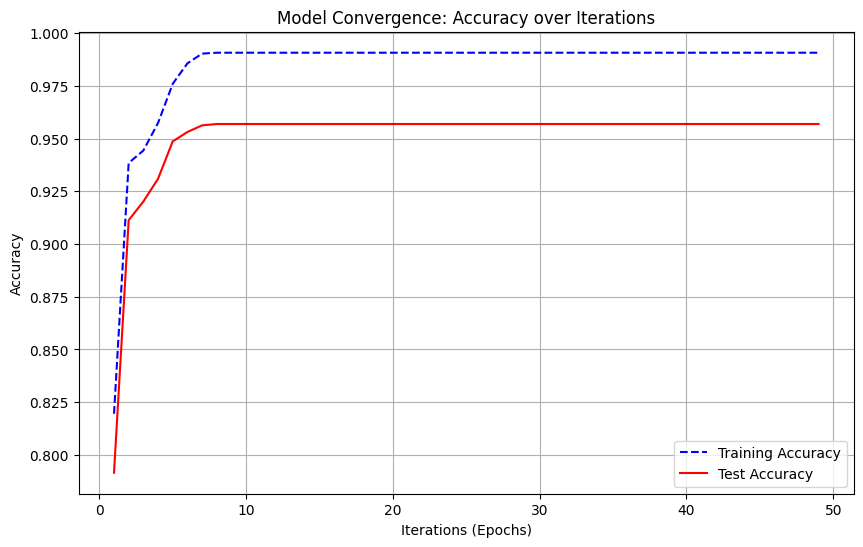

图表解读：
1. 随着迭代次数增加，模型逐渐收敛。
2. 红色曲线（测试集）代表模型的真实泛化能力。


In [13]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# 忽略收敛警告（因为我们在模拟未完成的训练状态）
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print("正在模拟迭代训练过程，绘制学习曲线...")

# 1. 初始化模型，开启 warm_start (允许增量训练)
# solver='lbfgs' 是默认的，但为了演示迭代，我们限制 max_iter
clf_vis = LogisticRegression(warm_start=True, max_iter=1, random_state=42, C=1.0)

train_acc = []
test_acc = []
iters = range(1, 50)  # 模拟前 50 次迭代

# 2. 逐步训练
for i in iters:
    clf_vis.max_iter = i  # 逐步增加最大迭代次数
    clf_vis.fit(X_train, y_train)
    
    # 记录当前的训练集和测试集准确率
    train_acc.append(clf_vis.score(X_train, y_train))
    test_acc.append(clf_vis.score(X_test, y_test))

# 3. 绘图
plt.figure(figsize=(10, 6))
plt.plot(iters, train_acc, label='Training Accuracy', color='blue', linestyle='--')
plt.plot(iters, test_acc, label='Test Accuracy', color='red')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Accuracy')
plt.title('Model Convergence: Accuracy over Iterations')
plt.legend()
plt.grid(True)
plt.show()

print("图表解读：")
print("1. 随着迭代次数增加，模型逐渐收敛。")
print("2. 红色曲线（测试集）代表模型的真实泛化能力。")

# 5.2学习曲线
数据量的大小，会对模型效果产生多大的影响？

正在计算样本量与模型效果的关系（这可能需要十几秒钟）...


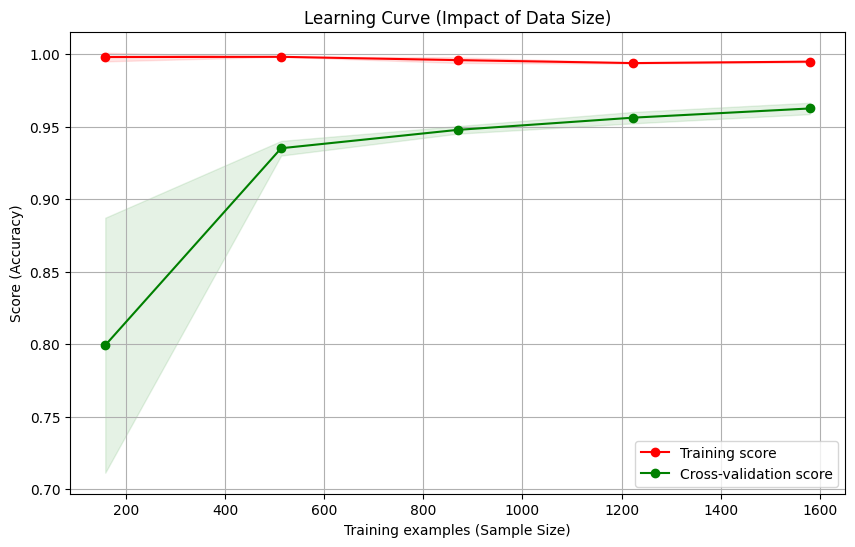

In [14]:
from sklearn.model_selection import learning_curve

print("正在计算样本量与模型效果的关系（这可能需要十几秒钟）...")

# 定义画图函数
def plot_learning_curve(estimator, title, X, y, cv=3):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5) # 从 10% 到 100% 的数据量
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples (Sample Size)")
    plt.ylabel("Score (Accuracy)")
    plt.grid()
    
    # 绘制区域和曲线
    plt.fill_between(train_sizes, train_scores_mean - np.std(train_scores, axis=1),
                     train_scores_mean + np.std(train_scores, axis=1), alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - np.std(test_scores, axis=1),
                     test_scores_mean + np.std(test_scores, axis=1), alpha=0.1, color="g")
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.legend(loc="best")
    plt.show()

# 调用函数绘制
plot_learning_curve(LogisticRegression(max_iter=1000), 
                    "Learning Curve (Impact of Data Size)", 
                    X_train, y_train)

## 6. 模型评估

查看模型在测试集上的分类准确度。

In [8]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {acc*100:.2f}%")

print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=newsgroups_train.target_names))

测试集准确率: 95.69%

分类报告:
                  precision    recall  f1-score   support

   comp.graphics       0.93      0.95      0.94       389
       rec.autos       0.95      0.96      0.96       396
rec.sport.hockey       0.99      0.98      0.98       399
       sci.space       0.96      0.93      0.95       394

        accuracy                           0.96      1578
       macro avg       0.96      0.96      0.96      1578
    weighted avg       0.96      0.96      0.96      1578



### 6.1 混淆矩阵
看看模型最容易把哪两个类别搞混？

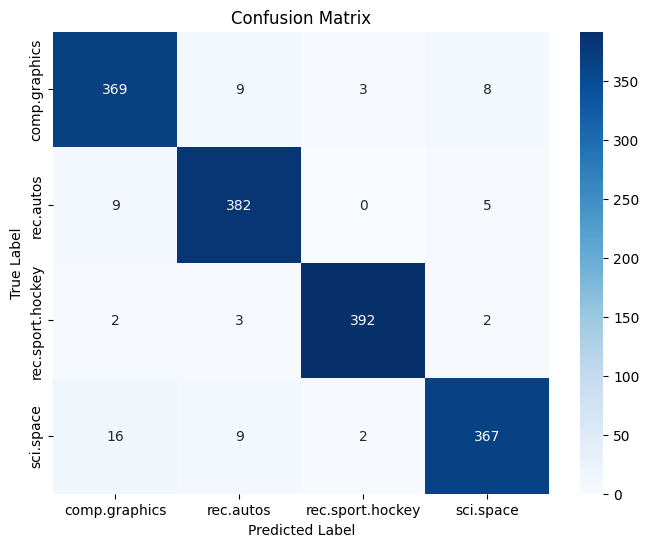

In [9]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=newsgroups_train.target_names, 
            yticklabels=newsgroups_train.target_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

## 7. 可解释性分析：模型“看”到了什么？

逻辑回归的好处是它有**权重 (Coefficients)**。权重越大的词，说明对该类别的贡献越大。
下面我们将可视化每个类别中**权重最高的前 10 个关键词**。

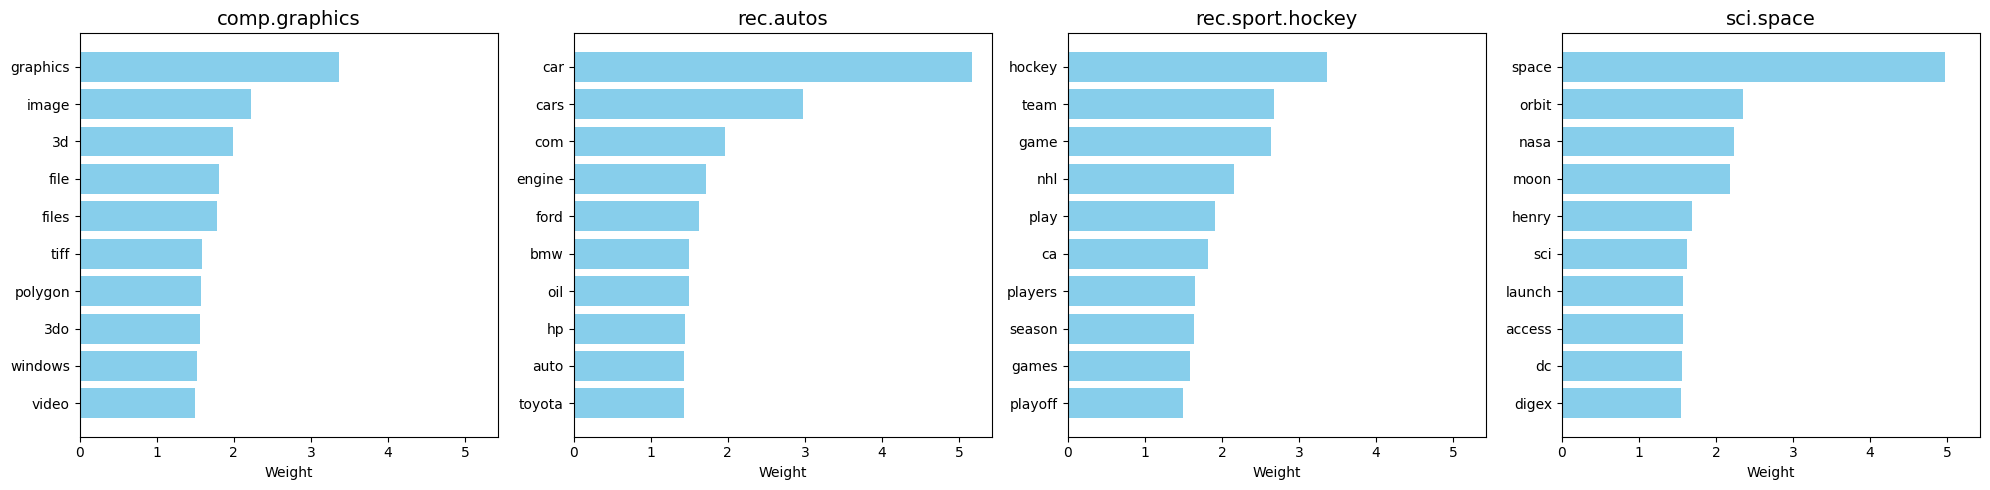

In [10]:
def plot_top_words(model, feature_names, n_top_words=10):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
    axes = axes.flatten()
    
    for i, label in enumerate(newsgroups_train.target_names):
        # 获取该类别的特征权重
        coefs = model.coef_[i]
        # 排序，取最大的前 n 个索引
        top_indices = np.argsort(coefs)[-n_top_words:]
        
        # 获取对应的词和权重
        top_words = [feature_names[j] for j in top_indices]
        top_weights = coefs[top_indices]
        
        # 画条形图
        axes[i].barh(top_words, top_weights, color='skyblue')
        axes[i].set_title(label, fontsize=14)
        axes[i].set_xlabel("Weight")
    
    plt.tight_layout()
    plt.show()

# 获取词汇表
feature_names = vectorizer.get_feature_names_out()
plot_top_words(clf, feature_names)

## 8. 动手试一试

输入一段你自己写的英文新闻标题，看看模型会把它分到哪一类？

In [12]:
# 自定义测试文本
my_texts = [
    "NASA launched a new rocket to the moon.",       # 应该是 Space
    "The driver won the championship with his Ferrari.", # 应该是 Autos
    "I need to buy a new graphics card for rendering.",  # 应该是 Graphics
    "The goalkeeper saved the final shot."	           # 应该是 Hockey
]

# 记得先 transform!
my_vecs = vectorizer.transform(my_texts)
my_preds = clf.predict(my_vecs)

for text, pred_idx in zip(my_texts, my_preds):
    print(f"文本: {text}")
    print(f"预测: {newsgroups_train.target_names[pred_idx]}\n")

文本: NASA launched a new rocket to the moon.
预测: sci.space

文本: The driver won the championship with his Ferrari.
预测: comp.graphics

文本: I need to buy a new graphics card for rendering.
预测: comp.graphics

文本: The goalkeeper saved the final shot.
预测: rec.sport.hockey



## 9. 拓展思考与挑战 (Discussion)

在完成实验后，请思考以下 3 个在实际工程中必然遇到的问题。

###  思考题
1.  **关于停用词 (Stop Words)**：
    如果我们在 `TfidfVectorizer` 中去掉 `stop_words='english'` 参数，让 "the", "is", "a" 这些词也参与训练，你认为模型的准确率会大幅下降吗？TF-IDF 算法本身对这些词有“免疫力”吗？

2.  **关于“从未见过的词” (OOV 问题)**：
    假设训练集中从没出现过 "ChatGPT" 这个词，但在测试的一篇新闻中出现了 "ChatGPT"。
    * 向量化步骤 (`transform`) 会报错吗？
    * 模型会如何处理这个词？

3.  **关于类别不平衡 (Class Imbalance)**：
    本实验中 4 个类别的样本量比较平均。如果现实中 `rec.sport.hockey`（冰球）的新闻有 9000 篇，而 `sci.space`（太空）只有 100 篇，直接用逻辑回归训练会发生什么问题？准确率（Accuracy）还是一个可靠的指标吗？

---

###  解答思路 (Answer Key)

> **建议先独立思考，再点击下方查看参考思路。**

<details>
<summary><strong>点击这里查看解答思路</strong></summary>

#### 1. 关于停用词
* **准确率影响**：通常**不会**大幅下降，甚至可能基本不变。
* **原因**：TF-IDF 中的 **IDF (逆文档频率)** 惩罚项发挥了作用。"the" 在几乎所有文档中都出现，所以它的 IDF 值接近于 0，最终计算出的 TF-IDF 权重也会极小。
* **那为什么还要去停用词？**：主要是为了**减少内存占用**和**计算量**。去掉几百个无意义的高频词，可以显著降低矩阵的稠密度。

#### 2. 关于 OOV (Out of Vocabulary)
* **会报错吗？**：**不会**。`CountVectorizer` 或 `TfidfVectorizer` 在 `transform` 测试集时，会自动忽略那些不在“词汇表”中的新词。
* **如何处理**：这个词在特征向量中对应的所有位置都是 **0**。模型完全“看”不到它，就好像它不存在一样。这是传统统计学 NLP 方法的一个主要劣势（相比于 Word2Vec 或 BERT）。

#### 3. 关于类别不平衡
* **后果**：模型会倾向于把所有样本都预测为“大类”（冰球），因为它只要无脑猜冰球，准确率就能达到 90% 以上。
* **指标失效**：此时 Accuracy 会虚高，具有欺骗性。
* **解决方案**：
    1.  **换指标**：必须看 Recall（召回率）和 F1-score，特别是小类（太空）的 F1 分数。
    2.  **加权重**：在 LogisticRegression 中设置 `class_weight='balanced'`，强制让模型更重视小样本类别。
</details>